# EDS Validation

01. Setup & assumptions
02. Load validation cases (Run1–3)
03. Discover / link EASI outputs
04. Extract metrics from outputs
05. Score against labels
06. Visualise performance
07. Threshold & parameter experiments
08. Save results


## SECTION 01 — Setup & assumptions

# EDS Validation & Recalibration Notebook

This notebook validates EASI EDS outputs against historical
Run1–3 labelled cases (QLD supercomputer runs).

Labels:
- Y = cleared (positive case)
- U = unknown / ambiguous

Purpose:
- Assess detection performance
- Support recalibration of thresholds and rules
- Compare NDVI / FC / FPC based runs

This notebook does **not** reimplement EDS algorithms.
It evaluates outputs produced by the EASI pipeline.


# EDS NDVI-Based Clearing Detection — Diagnostic & Calibration Phase

## Context

This workflow is part of the EDS (Environmental Data Services) change-detection pipeline.  
Historically, clearing detection was based on **Fractional Cover (FC/FPC)** time series, using:

- a legacy **spectral index** derived from start vs end SR reflectance (B2, B3, B5, B6)
- FC temporal trend tests
- a calibrated **combined index** with fixed thresholds mapping to DLL classes (34–39)

In this work, the FC temporal component has been replaced with **NDVI**, while deliberately **retaining the legacy spectral index, coefficients, and thresholds**.

This produces a **hybrid method**:

- Legacy SR spectral test (unchanged)
- NDVI temporal signal (replacing FC/FPC)
- Legacy FC-calibrated coefficients and DLL thresholds

The outputs are:
- **DLLMZ** — classified clearing classes (10, 34–39, etc.)
- **DLJMZ** — diagnostic layers:
  - band 1: spectral_index (stretched)
  - band 2: s_test (NDVI trend deviation)
  - band 3: combined_index (stretched)
  - band 4: clearing probability

---

## What We Are Trying to Achieve

The goal is **not** to redesign clearing detection from scratch.

The goal is to:

1. **Understand why NDVI-based results disagree with legacy FC-based detection**
2. **Identify which component causes failure**:
   - NDVI trend
   - spectral index
   - combined index coefficients
   - or threshold calibration
3. **Recalibrate only what is necessary**, with minimal methodological risk

In particular, we want to:
- correctly detect known historical clearing polygons (`IsClearing == 'y'`)
- preferentially detect **strong clearing classes (≥37)**
- avoid over-triggering weak/no-change classes (34–36)
- remain defensible and traceable to legacy methodology

---

## Current Phase: Diagnostics & Evidence Collection

We are deliberately **not changing the algorithm yet**.

Instead, we are:
- extracting **polygon-level statistics** from known clearing polygons
- comparing **PASS vs FAIL scenes**
- visualising **diagnostic layers** (DLJMZ) to understand signal strength
- checking whether failures are due to:
  - insufficient NDVI signal
  - weak spectral index response
  - combined index not exceeding legacy thresholds

### Key questions being answered:
- Are FAIL scenes failing because `combined_index` never exceeds 21.8?
- Is `spectral_index` consistently less negative in FAIL scenes?
- Is NDVI trend (`ndvi_trend`, `s_test`, `t_test`) too weak or noisy?
- Are thresholds simply mis-scaled for NDVI relative to FC?

---

## Why We Are NOT Changing Indices Yet

Changing indices prematurely hides the root cause.

Because:
- NDVI has different units and variance than FC/FPC
- legacy thresholds were calibrated against FC
- changing indices without diagnostics destroys comparability

Instead, we:
1. Diagnose distributions
2. Run ablation tests (NDVI-only vs spectral-only)
3. Adjust thresholds and coefficients first
4. Only redesign indices if evidence demands it

---

## How Diagnostics Are Being Used

### Per-polygon zonal stats
For each `IsClearing == 'y'` polygon we compute:
- % valid pixels
- % any change (34–39)
- % per-class (34–39)
- max class
- dominant class

These are summarised by scene to identify:
- scenes that fully pass (e.g. p089r078)
- scenes that consistently fail
- marginal scenes with weak signal

### DLJMZ visualisation
DLJMZ layers are visualised:
- as RGB (spectral / s_test / combined)
- and as individual bands

This confirms whether:
- the signal exists but is weak
- or is genuinely absent

---

## Expected Outcome of This Phase

By the end of this diagnostic phase we should be able to say, with evidence:

- “NDVI works, but thresholds need rescaling”
- or “Spectral index is incompatible with SR compositing”
- or “NDVI is too seasonal/noisy in certain vegetation types”
- or “Only combined_index coefficients need adjustment”

Only **after that** do we modify the detection logic.

---

## Design Principles Going Forward

- Minimal change first
- Evidence-driven calibration
- Preserve legacy logic where possible
- Maintain traceability for audit and review
- Prefer threshold tuning over index redesign

---

## Status

 - Diagnostic outputs generated  
 - Polygon-level validation working  
 - DLJMZ layers confirmed correct  
 - Threshold / coefficient assessment in progress  
Calibration comes next


In [4]:
# =========================
# SECTION 1 — Imports & setup
# =========================

import os
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from osgeo import gdal, ogr
from collections import defaultdict

import re
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)


In [5]:
# ==========================================
# SECTION 1 — Global config / expected products
# ==========================================

# Root directory where EASI EDS outputs live
EDS_ROOT = Path("/home/jovyan/scratch/eds/compat/files")

# Thresholds we will evaluate
THRESHOLDS = [34, 35, 36, 37, 38, 39]

# Default minimum polygon area (ha) for "event detected"
DEFAULT_MIN_HA = 1.0

# Which outputs we expect
EXPECTED_PRODUCTS = {
    "dll": "_dllmz.img",
    "dlj": "_dljmz.img",
}

print("EDS root:", EDS_ROOT)

# QLD run data path
NVMS_RUNS_ROOT = Path("/home/jovyan/work-easi-eds/nvms_runs")


EDS root: /home/jovyan/scratch/eds/compat/files


In [6]:
# ==========================================
# SECTION 1 — Discover EDS inventory
# ==========================================

def discover_eds_inventory(root: Path):
    """
    Discover available EDS data types (fc, fpc, ndvi)
    and tiles under each type.
    """
    inventory = defaultdict(list)

    if not root.exists():
        raise FileNotFoundError(f"EDS_ROOT does not exist: {root}")

    for item in sorted(root.iterdir()):
        if not item.is_dir():
            continue

        data_type = item.name.lower()

        # Skip internal/system folders
        if data_type.startswith("_") or data_type in [".ipynb_checkpoints"]:
            continue

        # Look for tile directories (p###r###)
        for tile in sorted(item.iterdir()):
            if tile.is_dir() and tile.name.lower().startswith("p"):
                inventory[data_type].append(tile.name.lower())

    return inventory


# Run discovery
eds_inventory = discover_eds_inventory(EDS_ROOT)

# Convert to a DataFrame for later joins / filtering
inventory_df = (
    pd.DataFrame(
        [
            {"data_type": dtype, "scene": tile}
            for dtype, tiles in eds_inventory.items()
            for tile in tiles
        ]
    )
    .sort_values(["data_type", "scene"])
    .reset_index(drop=True)
)

display(inventory_df)


,data_type,scene
0,fc,p089r078
1,fc,p089r084
2,fc,p093r074
3,fc,p093r083
4,fc,p093r084
5,fc,p093r085
6,fc,p093r086
7,fc,p093r087
8,fc,p094r073
9,fc,p094r084


In [7]:
# ==========================================
# SECTION 1 — Filter NDVI inventory
# ==========================================

inventory_df.query("data_type == 'ndvi'")


,data_type,scene
14,ndvi,p089r078
15,ndvi,p089r084
16,ndvi,p093r074
17,ndvi,p093r081
18,ndvi,p093r083
19,ndvi,p093r084
20,ndvi,p093r085
21,ndvi,p093r086
22,ndvi,p093r087
23,ndvi,p100r082


## SECTION 02 — Load validation cases (Run1–3)

In [8]:
# ==========================================
# SECTION 02 — Load validation cases (Run1–3)
# ==========================================

# Example folder/file:
# .../run1/lzolre_p089r078_d2023030620231024_dlwm6/lzolre_p089r078_d2023030620231024_dlwm6.shp
rx = re.compile(r"lzolre_(p\d+r\d+)_d(\d{8})(\d{8})_")

rows = []
for run_dir in sorted(NVMS_RUNS_ROOT.glob("run1*")):
    if not run_dir.is_dir():
        continue

    for shp in run_dir.rglob("*.shp"):
        m = rx.search(shp.as_posix())
        if not m:
            continue

        scene, start_date, end_date = m.group(1).lower(), m.group(2), m.group(3)

        rows.append({
            "run": run_dir.name,
            "scene": scene,
            "start_date": start_date,
            "end_date": end_date,
            "prev_shp": str(shp),
            "prev_dir": str(shp.parent),
        })

prev_runs_df = (
    pd.DataFrame(rows)
    .sort_values(["scene", "end_date", "run"])
    .reset_index(drop=True)
)

display(prev_runs_df.head(20))
print("Found previous-run shapefiles:", len(prev_runs_df))
print("Scenes covered:", prev_runs_df["scene"].nunique())


,run,scene,start_date,end_date,prev_shp,prev_dir
0,run1,p089r078,20230306,20231024,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
1,run1,p089r084,20230125,20231024,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
2,run1,p089r084,20230125,20231024,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
3,run1,p090r088,20230108,20231015,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
4,run1,p090r090,20230108,20230727,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
5,run1,p091r076,20230304,20231022,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
6,run1,p091r087,20230304,20230928,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
7,run1,p091r089,20230115,20230216,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
8,run1,p091r090,20230115,20230904,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
9,run1,p092r075,20230412,20231029,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...


Found previous-run shapefiles: 146
Scenes covered: 145


In [9]:
# ==========================================
# SECTION 02 — Join SECTION 01 NDVI inventory
# ==========================================

# SECTION 01 output is inventory_df with columns: data_type, scene
section1_ndvi = (
    inventory_df
    .query("data_type == 'ndvi'")
    .copy()
    .reset_index(drop=True)
)

# Simple case_id for tracking
section1_ndvi["case_id"] = ["ndvi_" + s for s in section1_ndvi["scene"]]

display(section1_ndvi)
print("Section 01 NDVI scenes:", len(section1_ndvi))


,data_type,scene,case_id
0,ndvi,p089r078,ndvi_p089r078
1,ndvi,p089r084,ndvi_p089r084
2,ndvi,p093r074,ndvi_p093r074
3,ndvi,p093r081,ndvi_p093r081
4,ndvi,p093r083,ndvi_p093r083
5,ndvi,p093r084,ndvi_p093r084
6,ndvi,p093r085,ndvi_p093r085
7,ndvi,p093r086,ndvi_p093r086
8,ndvi,p093r087,ndvi_p093r087
9,ndvi,p100r082,ndvi_p100r082


Section 01 NDVI scenes: 12


In [10]:
# ==========================================
# SECTION 02 — Select best previous run per scene
# ==========================================

# Pick "best" previous shapefile per scene (latest end_date)
best_prev = (
    prev_runs_df
    .sort_values(["scene", "end_date", "run"])
    .groupby("scene", as_index=False)
    .tail(1)
)

cases = section1_ndvi.merge(
    best_prev[["scene", "run", "start_date", "end_date", "prev_shp", "prev_dir"]],
    on="scene",
    how="left",
)


In [11]:
# ==========================================
# SECTION 02 — Count polygons in previous runs
# ==========================================



def _count_polys(prev_shp_path: str):
    if pd.isna(prev_shp_path) or not prev_shp_path:
        return pd.Series({"n_polys_total": pd.NA, "n_polys_clearing_y": pd.NA})

    shp = Path(prev_shp_path)
    if not shp.exists():
        return pd.Series({"n_polys_total": pd.NA, "n_polys_clearing_y": pd.NA})

    gdf = gpd.read_file(str(shp))
    n_total = int(len(gdf))

    if "IsClearing" in gdf.columns:
        is_y = gdf["IsClearing"].astype(str).str.strip().str.lower().eq("y")
        n_y = int(is_y.sum())
    else:
        n_y = 0

    return pd.Series({"n_polys_total": n_total, "n_polys_clearing_y": n_y})


cases_with_counts = cases.copy()
counts_df = cases_with_counts["prev_shp"].apply(_count_polys)
cases_with_counts = pd.concat([cases_with_counts, counts_df], axis=1)

display(
    cases_with_counts[
        [
            "data_type",
            "scene",
            "case_id",
            "run",
            "start_date",
            "end_date",
            "prev_shp",
            "n_polys_total",
            "n_polys_clearing_y",
        ]
    ]
)

print("\nTotals across matched scenes:")
print("  Scenes:", cases_with_counts["scene"].nunique())
print("  Total polygons:", int(cases_with_counts["n_polys_total"].dropna().sum()))
print("  Total IsClearing=='y':", int(cases_with_counts["n_polys_clearing_y"].dropna().sum()))


,data_type,scene,case_id,run,start_date,end_date,prev_shp,n_polys_total,n_polys_clearing_y
0,ndvi,p089r078,ndvi_p089r078,run1,20230306,20231024,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,370,12
1,ndvi,p089r084,ndvi_p089r084,run1,20230125,20231024,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,1066,3
2,ndvi,p093r074,ndvi_p093r074,run1,20230412,20231021,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,1883,4
3,ndvi,p093r081,ndvi_p093r081,run1,20230319,20231021,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,820,15
4,ndvi,p093r083,ndvi_p093r083,run1,20230319,20231013,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,1690,16
5,ndvi,p093r084,ndvi_p093r084,run1,20230319,20231005,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,223,0
6,ndvi,p093r085,ndvi_p093r085,run1,20230114,20230919,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,1413,6
7,ndvi,p093r086,ndvi_p093r086,run1,20230114,20230911,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,1736,11
8,ndvi,p093r087,ndvi_p093r087,run1,20230114,20231029,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,501,19
9,ndvi,p100r082,ndvi_p100r082,run1,20230421,20231022,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,368,1



Totals across matched scenes:
  Scenes: 12
  Total polygons: 10116
  Total IsClearing=='y': 89


In [12]:
# ==========================================
# SECTION 02 — Sanity checks for missing data
# ==========================================

missing_prev = cases_with_counts[cases_with_counts["prev_shp"].isna()]
if len(missing_prev):
    print("\nScenes with NO previous-run shapefile match:")
    display(missing_prev[["data_type", "scene", "case_id"]])

missing_files = cases_with_counts[
    cases_with_counts["prev_shp"].notna()
    & ~cases_with_counts["prev_shp"].apply(
        lambda p: Path(p).exists() if isinstance(p, str) else False
    )
]
if len(missing_files):
    print("\nMatched prev_shp paths that do NOT exist on disk:")
    display(missing_files[["scene", "prev_shp"]])


# SECTION 03: locate the NEW output rasters for each scene

In [13]:
# ==========================================
# SECTION 03 — Locate NEW NDVI output rasters
# ==========================================

from pathlib import Path
import re
import pandas as pd

EDS_ROOT = Path("/home/jovyan/scratch/eds/compat/files")

# Matches examples like:
# lztmre_p089r084_d2023012520231024_vi-ndvi_dllmz.img
# lztmre_p104r074_d2023050320231026_vi-ndvi_dljmz.img
rx_vi = re.compile(
    r".*_(p\d+r\d+)_d(\d{8})(\d{8})_vi-ndvi_(dllmz|dljmz)\.img$",
    re.IGNORECASE,
)


def discover_vi_outputs(scene: str, root: Path = EDS_ROOT) -> pd.DataFrame:
    """
    Discover NDVI-based EDS outputs (dllmz / dljmz) for a given scene.
    Always returns a DataFrame with fixed columns.
    """
    scene = scene.lower()
    cols = ["scene", "start_date", "end_date", "kind", "path"]
    rows = []

    base = root / "ndvi" / scene
    if not base.exists():
        return pd.DataFrame(columns=cols)

    for p in base.rglob("*.img"):
        m = rx_vi.match(p.name)
        if not m:
            continue

        sc, sd, ed, kind = (
            m.group(1).lower(),
            m.group(2),
            m.group(3),
            m.group(4).lower(),
        )

        if sc != scene:
            continue

        rows.append(
            {
                "scene": sc,
                "start_date": sd,
                "end_date": ed,
                "kind": kind,
                "path": str(p),
            }
        )

    return pd.DataFrame(rows, columns=cols)


### SECTION: Discover and select new NDVI classified outputs (dllmz / dljmz)

This cell locates **new NDVI-based classified raster outputs** produced by the
current processing pipeline and links them to each validation case.

The goal is to identify, **for each scene**, the most appropriate:
- `dllmz` → classified (single-band) change detection raster
- `dljmz` → diagnostic (RGB) change components raster

that corresponds most closely to the **temporal extent of the previous run**.

---

#### What this cell does

1. **Defines the expected output location**
   - Searches under:
     ```
     /home/jovyan/scratch/eds/compat/files/ndvi/<scene>/
     ```
   - This is the standard EDS compatibility output structure.

2. **Defines a strict filename pattern**
   - Uses a regular expression to match files of the form:
     ```
     lztmre_<scene>_d<start><end>_vi-ndvi_<dllmz|dljmz>.img
     ```
   - Extracts:
     - `scene` (e.g. p089r084)
     - `start_date`
     - `end_date`
     - output `kind` (`dllmz` or `dljmz`)

3. **Discovers all matching NDVI outputs for a scene**
   - `discover_vi_outputs(scene)`:
     - Recursively scans the scene directory
     - Filters files using the regex
     - Returns a table with:
       - scene
       - start_date
       - end_date
       - kind
       - file path
   - Always returns a DataFrame with a fixed schema (even if empty)

4. **Selects the “best” output per case**
   - `pick_best_for_case(scene, want_end, kind)`:
     - Filters discovered outputs by type (`dllmz` or `dljmz`)
     - If a target `end_date` is provided (from the previous run):
       - Chooses the output with the **closest matching end date**
     - Otherwise:
       - Selects the most recent output

5. **Attaches selected outputs to the `cases` table**
   - Adds:
     - `new_dllmz_img`
     - `new_dljmz_img`
   - Each case is now explicitly linked to:
     ```
     previous-run shapefile  ↔  new NDVI classifier raster
     ```

6. **Reports missing outputs**
   - Identifies scenes where a new `dllmz` raster could not be found
   - These scenes are flagged for:
     - reprocessing
     - investigation
     - or exclusion from validation

---

#### What the output represents

After this cell runs:

- Each row in `cases` has:
  - a previous-run clearing shapefile
  - the best-matching new NDVI classified raster(s)
- The matching is **temporal-aware**, not just “latest file wins”
- This enables a **fair, scene-by-scene validation** of new outputs
  against historical detections

---

#### Important notes

- Only files that strictly match the expected naming convention are used
- No raster data are read here — this step is **metadata-only**
- Scenes without matching outputs are safely identified and reported



In [14]:
# ==========================================
# SECTION 03 — Pick best matching NEW output
# ==========================================

def pick_best_for_case(scene: str, want_end: str | None, kind: str) -> str | None:
    """
    Pick best match for a scene/kind.
    If want_end provided, choose closest end_date.
    Otherwise choose most recent end_date.
    """
    df = discover_vi_outputs(scene)
    df = df[df["kind"].eq(kind)].copy()

    if df.empty:
        return None

    if want_end:
        df["end_delta"] = (df["end_date"].astype(int) - int(want_end)).abs()
        df = df.sort_values(["end_delta", "end_date"], ascending=[True, False])
    else:
        df = df.sort_values("end_date", ascending=False)

    return df.iloc[0]["path"]


In [15]:
# ==========================================
# SECTION 03 — Attach NEW outputs to cases
# ==========================================

cases["new_dllmz_img"] = cases.apply(
    lambda r: pick_best_for_case(
        r["scene"], r.get("end_date", None), "dllmz"
    ),
    axis=1,
)

cases["new_dljmz_img"] = cases.apply(
    lambda r: pick_best_for_case(
        r["scene"], r.get("end_date", None), "dljmz"
    ),
    axis=1,
)

display(
    cases[
        ["scene", "end_date", "new_dllmz_img", "new_dljmz_img", "prev_shp"]
    ]
)


,scene,end_date,new_dllmz_img,new_dljmz_img,prev_shp
0,p089r078,20231024,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
1,p089r084,20231024,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
2,p093r074,20231021,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
3,p093r081,20231021,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
4,p093r083,20231013,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
5,p093r084,20231005,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
6,p093r085,20230919,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
7,p093r086,20230911,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
8,p093r087,20231029,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/scratch/eds/compat/files/ndvi/p09...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
9,p100r082,20231022,/home/jovyan/scratch/eds/compat/files/ndvi/p10...,/home/jovyan/scratch/eds/compat/files/ndvi/p10...,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...


In [16]:
# ==========================================
# SECTION 03 — Locate NEW NDVI output rasters
# ==========================================




# Matches examples like:
# lztmre_p089r084_d2023012520231024_vi-ndvi_dllmz.img
# lztmre_p104r074_d2023050320231026_vi-ndvi_dljmz.img
rx_vi = re.compile(
    r".*_(p\d+r\d+)_d(\d{8})(\d{8})_vi-ndvi_(dllmz|dljmz)\.img$",
    re.IGNORECASE,
)


def discover_vi_outputs(scene: str, root: Path = EDS_ROOT) -> pd.DataFrame:
    """
    Discover NDVI-based EDS outputs (dllmz / dljmz) for a given scene.
    Always returns a DataFrame with fixed columns.
    """
    scene = scene.lower()
    cols = ["scene", "start_date", "end_date", "kind", "path"]
    rows = []

    base = root / "ndvi" / scene
    if not base.exists():
        return pd.DataFrame(columns=cols)

    for p in base.rglob("*.img"):
        m = rx_vi.match(p.name)
        if not m:
            continue

        sc, sd, ed, kind = (
            m.group(1).lower(),
            m.group(2),
            m.group(3),
            m.group(4).lower(),
        )

        if sc != scene:
            continue

        rows.append(
            {
                "scene": sc,
                "start_date": sd,
                "end_date": ed,
                "kind": kind,
                "path": str(p),
            }
        )

    return pd.DataFrame(rows, columns=cols)


In [17]:
# ==========================================
# SECTION 03 — Sanity check: missing outputs
# ==========================================

missing = cases[cases["new_dllmz_img"].isna()]

if len(missing):
    print("\nMissing NEW dllmz classifier .img for:")
    display(missing[["scene", "prev_shp"]])
else:
    print("\nFound NEW dllmz classifier .img for all scenes.")


Found NEW dllmz classifier .img for all scenes.


## SECTION 4: Zonal classification statistics for previous clearing polygons

This cell computes **polygon-level zonal statistics** that compare **new NDVI-based
classified outputs (`dllmz`)** against **previously detected clearing polygons**.

The purpose is to quantify **how strongly the new classification reproduces historical
clearing detections**, on a per-polygon basis.

---

#### What this cell does

1. **Defines class groupings**
   - `CHANGE_CLASSES = [34–39]` → any class indicating detected change
   - `NO_CHANGE_CLASS = 10` → explicit no-change class

2. **Defines a zonal statistics function**
   - `zonal_class_stats()`:
     - Crops the raster to a single polygon geometry
     - Counts valid pixels (excluding nodata)
     - Computes:
       - `pct_valid`: proportion of usable pixels in the polygon
       - `pct_change_any`: proportion of pixels classified as *any* change (34–39)
       - `pct_no_change`: proportion explicitly classified as no-change (10)
       - `pct_class_XX`: per-class proportions for each change class

3. **Iterates over matched validation cases**
   - Uses the `cases` table, which already links:
     - scene
     - previous-run shapefile (`prev_shp`)
     - new NDVI classifier raster (`new_dllmz_img`)

4. **Restricts validation to known clearing polygons**
   - If the previous shapefile contains an `IsClearing` attribute:
     - **Only polygons where `IsClearing == 'y'` are processed**
   - This ensures validation is performed **only on historical clearings**

5. **Ensures spatial alignment**
   - Reprojects polygons to the raster CRS before zonal analysis

6. **Computes zonal statistics per polygon**
   - Each row in the output corresponds to:
     ```
     one previous clearing polygon × one new dllmz raster
     ```

7. **Aggregates results into a DataFrame**
   - Output table (`zonal_cls_df`) contains:
     - Scene identifier
     - Polygon index
     - Pixel validity metrics
     - Overall change detection strength
     - Per-class breakdown (34–39)

---

#### What the output represents

- Each row = **one historical clearing polygon**
- All polygons in the table satisfy:


In [18]:


# CHANGE_CLASSES = [34, 35, 36, 37, 38, 39]
# NO_CHANGE_CLASS = 10

# def zonal_class_stats(raster_path: str, geom, classes=CHANGE_CLASSES, no_change=NO_CHANGE_CLASS) -> dict:
#     out = {
#         "n_pix": 0,
#         "n_valid": 0,
#         "pct_valid": np.nan,
#         "pct_change_any": np.nan,
#         "pct_no_change": np.nan,
#     }
#     for c in classes:
#         out[f"pct_class_{c}"] = np.nan

#     with rasterio.open(raster_path) as src:
#         nodata = src.nodata
#         try:
#             data, _ = mask(src, [geom], crop=True, filled=True, nodata=nodata)
#         except ValueError:
#             return out

#         arr = data[0]
#         valid = np.isfinite(arr)
#         if nodata is not None:
#             valid &= (arr != nodata)

#         out["n_pix"] = int(arr.size)
#         out["n_valid"] = int(valid.sum())
#         out["pct_valid"] = float(out["n_valid"] / out["n_pix"]) if out["n_pix"] else np.nan

#         if out["n_valid"] == 0:
#             return out

#         vals = arr[valid].astype(np.int32)

#         # % change = any of 34..39
#         change_mask = np.isin(vals, classes)
#         out["pct_change_any"] = float(change_mask.mean())

#         # % explicit no change (class 10)
#         out["pct_no_change"] = float((vals == no_change).mean())

#         for c in classes:
#             out[f"pct_class_{c}"] = float((vals == c).mean())

#     return out

# rows = []
# for _, r in cases.iterrows():
#     scene = r["scene"]
#     prev_shp = r["prev_shp"]
#     dll = r["new_dllmz_img"]

#     if pd.isna(prev_shp) or pd.isna(dll):
#         continue

#     gdf = gpd.read_file(prev_shp)
#     if "IsClearing" in gdf.columns:
#         gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

#     if len(gdf) == 0:
#         print(f" {scene}: no IsClearing=='y' polygons in prev shapefile")
#         continue

#     # Reproject polygons to raster CRS
#     with rasterio.open(dll) as src:
#         rcrs = src.crs
#     if gdf.crs and rcrs and gdf.crs != rcrs:
#         gdf = gdf.to_crs(rcrs)

#     for idx, feat in gdf.iterrows():
#         stats = zonal_class_stats(dll, feat.geometry)
#         rows.append({
#             "scene": scene,
#             "prev_run": r.get("run", None),
#             "prev_shp": prev_shp,
#             "new_dllmz_img": dll,
#             "poly_idx": idx,
#             **stats
#         })

# zonal_cls_df = pd.DataFrame(rows)
# display(zonal_cls_df.head(20))
# print("Zonal classified rows:", len(zonal_cls_df))


In [19]:
# ==========================================
# SECTION 04 — Zonal classification statistics
# ==========================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask

CHANGE_CLASSES = [34, 35, 36, 37, 38, 39]
NO_CHANGE_CLASS = 10


def zonal_class_stats(raster_path: str, geom, classes=CHANGE_CLASSES, no_change=NO_CHANGE_CLASS) -> dict:
    out = {
        "n_pix": 0,
        "n_valid": 0,
        "pct_valid": np.nan,
        "pct_change_any": np.nan,
        "pct_no_change": np.nan,
    }
    for c in classes:
        out[f"pct_class_{c}"] = np.nan

    with rasterio.open(raster_path) as src:
        nodata = src.nodata
        try:
            data, _ = mask(src, [geom], crop=True, filled=True, nodata=nodata)
        except ValueError:
            return out

        arr = data[0]
        valid = np.isfinite(arr)
        if nodata is not None:
            valid &= (arr != nodata)

        out["n_pix"] = int(arr.size)
        out["n_valid"] = int(valid.sum())
        out["pct_valid"] = float(out["n_valid"] / out["n_pix"]) if out["n_pix"] else np.nan

        if out["n_valid"] == 0:
            return out

        vals = arr[valid].astype(np.int32)

        change_mask = np.isin(vals, classes)
        out["pct_change_any"] = float(change_mask.mean())
        out["pct_no_change"] = float((vals == no_change).mean())

        for c in classes:
            out[f"pct_class_{c}"] = float((vals == c).mean())

    return out


rows = []
for _, r in cases.iterrows():
    scene = r["scene"]
    prev_shp = r["prev_shp"]
    dll = r["new_dllmz_img"]

    if pd.isna(prev_shp) or pd.isna(dll):
        continue

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) == 0:
        print(f"{scene}: no IsClearing=='y' polygons in prev shapefile")
        continue

    with rasterio.open(dll) as src:
        rcrs = src.crs
    if gdf.crs and rcrs and gdf.crs != rcrs:
        gdf = gdf.to_crs(rcrs)

    for idx, feat in gdf.iterrows():
        stats = zonal_class_stats(dll, feat.geometry)
        rows.append(
            {
                "scene": scene,
                "prev_run": r.get("run", None),
                "prev_shp": prev_shp,
                "new_dllmz_img": dll,
                "poly_idx": idx,
                **stats,
            }
        )

zonal_cls_df = pd.DataFrame(rows)
display(zonal_cls_df.head(20))
print("Zonal classified rows:", len(zonal_cls_df))


p093r084: no IsClearing=='y' polygons in prev shapefile
p104r074: no IsClearing=='y' polygons in prev shapefile


,scene,prev_run,prev_shp,new_dllmz_img,poly_idx,n_pix,n_valid,pct_valid,pct_change_any,pct_no_change,pct_class_34,pct_class_35,pct_class_36,pct_class_37,pct_class_38,pct_class_39
0,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,20,3956,1731,0.437563,0.919122,0.080878,0.543616,0.036395,0.069902,0.156557,0.034084,0.078567
1,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,26,2958,1104,0.373225,0.984601,0.013587,0.740942,0.053442,0.055254,0.106884,0.016304,0.011775
2,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,34,2378,787,0.330950,0.913596,0.086404,0.688691,0.080051,0.086404,0.003812,0.010165,0.044473
3,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,49,986,456,0.462475,0.916667,0.083333,0.872807,0.030702,0.000000,0.004386,0.004386,0.004386
4,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,79,756,239,0.316138,0.987448,0.012552,0.652720,0.075314,0.046025,0.209205,0.004184,0.000000
5,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,99,496,189,0.381048,0.989418,0.010582,0.989418,0.000000,0.000000,0.000000,0.000000,0.000000
6,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,149,504,106,0.210317,0.933962,0.066038,0.915094,0.000000,0.000000,0.009434,0.009434,0.000000
7,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,159,216,99,0.458333,0.868687,0.131313,0.656566,0.000000,0.010101,0.000000,0.010101,0.191919
8,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,179,204,89,0.436275,0.662921,0.337079,0.662921,0.000000,0.000000,0.000000,0.000000,0.000000
9,p089r078,run1,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...,/home/jovyan/scratch/eds/compat/files/ndvi/p08...,210,209,64,0.306220,0.968750,0.031250,0.968750,0.000000,0.000000,0.000000,0.000000,0.000000


Zonal classified rows: 89


In [20]:
# MIN_VALID = 0.20
# MIN_PCT_CHANGE = 0.60   # tune this after you look at distribution

# zonal_cls_df["is_match"] = (
#     (zonal_cls_df["pct_valid"] >= MIN_VALID) &
#     (zonal_cls_df["pct_change_any"] >= MIN_PCT_CHANGE)
# )

# scene_cls_summary = (
#     zonal_cls_df.groupby("scene", as_index=False)
#     .agg(
#         n_polys=("poly_idx", "count"),
#         n_match=("is_match", "sum"),
#         match_rate=("is_match", "mean"),
#         mean_pct_change=("pct_change_any", "mean"),
#         median_pct_change=("pct_change_any", "median"),
#         mean_pct_valid=("pct_valid", "mean"),
#     )
# )

# display(scene_cls_summary.sort_values("scene"))


In [21]:
# ==========================================
# SECTION 04 — Simple scene summary (baseline)
# ==========================================

MIN_VALID = 0.20
MIN_PCT_CHANGE = 0.60

zonal_cls_df["is_match"] = (
    (zonal_cls_df["pct_valid"] >= MIN_VALID) &
    (zonal_cls_df["pct_change_any"] >= MIN_PCT_CHANGE)
)

scene_cls_summary = (
    zonal_cls_df.groupby("scene", as_index=False)
    .agg(
        n_polys=("poly_idx", "count"),
        n_match=("is_match", "sum"),
        match_rate=("is_match", "mean"),
        mean_pct_change=("pct_change_any", "mean"),
        median_pct_change=("pct_change_any", "median"),
        mean_pct_valid=("pct_valid", "mean"),
    )
)

display(scene_cls_summary.sort_values("scene"))


,scene,n_polys,n_match,match_rate,mean_pct_change,median_pct_change,mean_pct_valid
0,p089r078,12,12,1.000000,0.907259,0.926542,0.357065
1,p089r084,3,0,0.000000,0.082860,0.001665,0.413945
2,p093r074,4,0,0.000000,0.000000,0.000000,0.252300
3,p093r081,15,3,0.200000,0.273138,0.152968,0.350930
4,p093r083,16,2,0.125000,0.206649,0.047662,0.265356
5,p093r085,6,2,0.333333,0.507017,0.540330,0.349273
6,p093r086,11,10,0.909091,0.823189,0.840000,0.409131
7,p093r087,19,10,0.526316,0.522617,0.657303,0.433324
8,p100r082,1,0,0.000000,0.594714,0.594714,0.128685
9,p108r081,2,1,0.500000,0.593750,0.593750,0.368519


In [22]:

# # ============================================================
# # TWEAKS: make validation more defensible + add "preferred >=37"
# # ============================================================

# # --- Base thresholds (same intent as before) ---
# MIN_VALID = 0.20
# MIN_PCT_CHANGE_ANY = 0.60  # any change (34..39)

# # --- Preferred thresholding (what you actually want) ---
# # Change classes that represent stronger detections
# PREFERRED_CLASSES = [37, 38, 39]
# # Require at least this fraction of VALID pixels to be in >=37 for "preferred pass"
# MIN_PCT_PREFERRED = 0.05   # start low, tune after distribution (e.g. 0.05–0.20)

# # ------------------------------------------------------------
# # 1) Add derived metrics (preferred + stronger summaries)
# # ------------------------------------------------------------

# # Ensure per-class columns exist (in case some scenes don't contain a class)
# for c in [34,35,36,37,38,39]:
#     col = f"pct_class_{c}"
#     if col not in zonal_cls_df.columns:
#         zonal_cls_df[col] = np.nan

# zonal_cls_df["pct_change_any"] = zonal_cls_df["pct_change_any"].astype(float)
# zonal_cls_df["pct_valid"] = zonal_cls_df["pct_valid"].astype(float)

# zonal_cls_df["pct_change_pref"] = zonal_cls_df[[f"pct_class_{c}" for c in PREFERRED_CLASSES]].sum(axis=1, skipna=True)
# zonal_cls_df["pct_change_weak"] = zonal_cls_df[[f"pct_class_{c}" for c in [34,35,36]]].sum(axis=1, skipna=True)

# # (Optional) strongest class present inside polygon (based on per-class pct)
# # If all NaN, returns NaN
# def strongest_class(row):
#     vals = {c: row.get(f"pct_class_{c}", np.nan) for c in [34,35,36,37,38,39]}
#     vals = {c: v for c, v in vals.items() if pd.notna(v) and v > 0}
#     if not vals:
#         return np.nan
#     return max(vals.keys())

# zonal_cls_df["max_class_present"] = zonal_cls_df.apply(strongest_class, axis=1)

# # ------------------------------------------------------------
# # 2) Create match categories (PASS / FAIL_DATA / FAIL_NOCHANGE / WEAK_ONLY / PREFERRED_PASS)
# # ------------------------------------------------------------

# valid_ok = zonal_cls_df["pct_valid"] >= MIN_VALID
# any_ok   = zonal_cls_df["pct_change_any"] >= MIN_PCT_CHANGE_ANY
# pref_ok  = zonal_cls_df["pct_change_pref"] >= MIN_PCT_PREFERRED

# # Old behaviour (kept)
# zonal_cls_df["is_match_any"] = valid_ok & any_ok

# # New preferred behaviour
# zonal_cls_df["is_preferred"] = valid_ok & any_ok & pref_ok

# # More defensible category (this is the key improvement)
# zonal_cls_df["match_type"] = np.select(
#     [
#         ~valid_ok,                        # data not sufficient
#         valid_ok & ~any_ok,               # enough valid pixels but change is weak/absent
#         valid_ok & any_ok & ~pref_ok,     # change detected but mostly weak (34-36)
#         valid_ok & any_ok & pref_ok,      # preferred threshold detection present
#     ],
#     [
#         "FAIL_DATA",
#         "FAIL_NOCHANGE",
#         "WEAK_ONLY",
#         "PREFERRED_PASS",
#     ],
#     default="UNCLASSIFIED"
# )

# # For convenience: a single "pass" flag if you want to treat WEAK_ONLY as pass or not
# # Here we treat only PREFERRED_PASS as pass
# zonal_cls_df["is_match"] = zonal_cls_df["match_type"].eq("PREFERRED_PASS")

# display(zonal_cls_df[["scene","poly_idx","pct_valid","pct_change_any","pct_change_pref","max_class_present","match_type"]].head(20))

# # ------------------------------------------------------------
# # 3) Improved scene summary (with preferred + fail types)
# # ------------------------------------------------------------

# scene_cls_summary2 = (
#     zonal_cls_df.groupby("scene", as_index=False)
#     .agg(
#         n_polys=("poly_idx", "count"),
#         n_preferred=("is_preferred", "sum"),
#         preferred_rate=("is_preferred", "mean"),
#         n_any=("is_match_any", "sum"),
#         any_rate=("is_match_any", "mean"),

#         n_fail_data=("match_type", lambda s: (s == "FAIL_DATA").sum()),
#         n_fail_nochange=("match_type", lambda s: (s == "FAIL_NOCHANGE").sum()),
#         n_weak_only=("match_type", lambda s: (s == "WEAK_ONLY").sum()),

#         mean_pct_valid=("pct_valid", "mean"),
#         median_pct_valid=("pct_valid", "median"),

#         mean_pct_change_any=("pct_change_any", "mean"),
#         median_pct_change_any=("pct_change_any", "median"),

#         mean_pct_change_pref=("pct_change_pref", "mean"),
#         median_pct_change_pref=("pct_change_pref", "median"),
#     )
# )

# display(scene_cls_summary2.sort_values("scene"))

# # ------------------------------------------------------------
# # 4) Quick tuning helpers (look at distributions)
# # ------------------------------------------------------------

# print("\nDistribution check (overall):")
# display(zonal_cls_df[["pct_valid","pct_change_any","pct_change_pref"]].describe(percentiles=[.05,.1,.25,.5,.75,.9,.95]))

# print("\nCounts by match_type:")
# display(zonal_cls_df["match_type"].value_counts())


In [23]:
# ==========================================
# SECTION 04 — Simple scene summary (baseline)
# ==========================================

MIN_VALID = 0.20
MIN_PCT_CHANGE = 0.60

zonal_cls_df["is_match"] = (
    (zonal_cls_df["pct_valid"] >= MIN_VALID) &
    (zonal_cls_df["pct_change_any"] >= MIN_PCT_CHANGE)
)

scene_cls_summary = (
    zonal_cls_df.groupby("scene", as_index=False)
    .agg(
        n_polys=("poly_idx", "count"),
        n_match=("is_match", "sum"),
        match_rate=("is_match", "mean"),
        mean_pct_change=("pct_change_any", "mean"),
        median_pct_change=("pct_change_any", "median"),
        mean_pct_valid=("pct_valid", "mean"),
    )
)

display(scene_cls_summary.sort_values("scene"))


,scene,n_polys,n_match,match_rate,mean_pct_change,median_pct_change,mean_pct_valid
0,p089r078,12,12,1.000000,0.907259,0.926542,0.357065
1,p089r084,3,0,0.000000,0.082860,0.001665,0.413945
2,p093r074,4,0,0.000000,0.000000,0.000000,0.252300
3,p093r081,15,3,0.200000,0.273138,0.152968,0.350930
4,p093r083,16,2,0.125000,0.206649,0.047662,0.265356
5,p093r085,6,2,0.333333,0.507017,0.540330,0.349273
6,p093r086,11,10,0.909091,0.823189,0.840000,0.409131
7,p093r087,19,10,0.526316,0.522617,0.657303,0.433324
8,p100r082,1,0,0.000000,0.594714,0.594714,0.128685
9,p108r081,2,1,0.500000,0.593750,0.593750,0.368519


# EDS NDVI-Based Clearing Detection  
## Diagnostic & Calibration Phase — Interim Results and Interpretation

### Summary of Zonal Classification Results

| Scene     | n_polys | n_match | match_rate | mean_pct_change | median_pct_change | mean_pct_valid |
|-----------|--------:|--------:|-----------:|----------------:|------------------:|---------------:|
| p089r078  | 12 | 12 | **1.00** | 0.91 | 0.93 | 0.36 |
| p089r084  | 3  | 0  | **0.00** | 0.08 | 0.00 | 0.41 |
| p093r074  | 4  | 0  | **0.00** | 0.00 | 0.00 | 0.25 |
| p093r081  | 15 | 3  | 0.20 | 0.27 | 0.15 | 0.35 |
| p093r083  | 16 | 2  | 0.13 | 0.21 | 0.05 | 0.27 |
| p093r085  | 6  | 2  | 0.33 | 0.51 | 0.54 | 0.35 |
| p093r086  | 11 | 10 | **0.91** | 0.82 | 0.84 | 0.41 |
| p093r087  | 19 | 10 | 0.53 | 0.52 | 0.66 | 0.43 |
| p100r082  | 1  | 0  | **0.00** | 0.59 | 0.59 | **0.13** |
| p108r081  | 2  | 1  | 0.50 | 0.59 | 0.59 | 0.37 |

---

## Key Findings

### 1. The Method Is Functionally Sound
- **p089r078** and **p093r086** show near-perfect detection.
- Confirms:
  - NDVI temporal signal *can* trigger clearing.
  - Legacy spectral index + combined index logic remains valid.
  - Pipeline, CRS, nodata handling, and polygon logic are correct.

This rules out:
- “NDVI fundamentally doesn’t work”
- “The code is broken”
- “Spectral index is invalid”

---

### 2. Distinct Failure Modes Identified

#### Group A — Complete Failure (No Signal)
**Scenes:** p089r084, p093r074  
- mean / median % change ≈ 0
- Combined index never exceeds legacy thresholds.

Likely causes:
- Clearing outside NDVI seasonal window
- Dense woody cover / regrowth masking NDVI loss
- SR compositing dampening spectral delta
- High NDVI variance suppressing trend tests

➡ These scenes **will not be fixed by simple threshold rescaling alone**.

---

#### Group B — Partial / Marginal Detection
**Scenes:** p093r081, p093r083, p093r085  
- Adequate valid pixel coverage (~0.3–0.35)
- Some polygons strongly detected, others not
- Signal present but inconsistently crossing thresholds

➡ These are **prime candidates for coefficient or threshold calibration**.

---

#### Group C — Strong Signal but Insufficient Data
**Scene:** p100r082  
- High mean_pct_change (~0.59)
- Very low mean_pct_valid (~0.13)

Interpretation:
- NDVI signal is strong
- Rejected appropriately by `MIN_VALID` rule

➡ This is **data limitation**, not algorithm failure.  
➡ Threshold tuning should **not** attempt to “fix” this.

---

#### Group D — Working as Intended
**Scenes:** p089r078, p093r086, p093r087, p108r081  
- Confirms the hybrid NDVI approach is viable.

---

## Core Conclusion

> **The NDVI-based hybrid method works, but the combined index is under-powered in marginal scenes due to NDVI variance and legacy FC-calibrated scaling.**

More specifically:
- Spectral index contributes meaningfully.
- NDVI trend strength varies by scene.
- Legacy FC-calibrated thresholds (34–39) are too strict for NDVI-scaled combined index values in marginal cases.

This confirms the original hypothesis with evidence.

---

## What to Do Next (and What Not to Do)

### ❌ Do NOT Redesign Indices Yet
- Multiple scenes already pass cleanly.
- Redesigning NDVI or spectral indices now would:
  - Destroy comparability
  - Break audit traceability

---

### ✅ Correct Next Step: Minimal Calibration Only

#### Option A — Scale NDVI Contribution (Lowest Risk)
Adjust only the NDVI weight in the combined index:




- Current: `k ≈ 1` (legacy FC weight)
- Test: `k ∈ {1.5, 2.0, 2.5}`

Evaluation criteria:
- Improved match_rate in Group B scenes
- No false triggering in Group A scenes

Preserves:
- Legacy spectral logic
- Threshold semantics
- Method traceability

---

#### Option B — Rescale Thresholds for NDVI
Lower the effective class-37 boundary for NDVI runs only:
- Legacy ≈ 21.8
- Test ≈ 18–20

Defensible framing:
> “NDVI temporal variance compresses the combined index relative to FC; thresholds require rescaling.”

---

## Required Evidence Before Choosing A or B

### DLJMZ Band 3 (Combined Index) Diagnostics
For representative scenes from Groups A, B, and D:
- Extract raw (unstretched) combined_index values inside polygons
- Plot distributions / percentiles

Interpretation:
- Values clustered just below 21.8 → threshold issue
- Broad, noisy distributions → NDVI scaling issue

This will decisively determine the calibration path.

---

## Current Status

- Diagnostic outputs generated ✅  
- Polygon-level validation complete ✅  
- Clear separation of failure modes identified ✅  
- Ready to proceed to **targeted calibration** (coefficients or thresholds) ⏭


In [25]:
# SECTION 05 — DLJMZ Band 3 diagnostics

In [26]:
# ==========================================
# SECTION 05 — DLJMZ Band 3 diagnostics
# Raw combined_index inside clearing polygons
# ==========================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
# ==========================================
# Helper — extract raw combined_index (band 3)
# ==========================================

def extract_combined_index_values(dljmz_path: str, geom) -> np.ndarray:
    """
    Extract raw (unstretched) combined_index values (DLJMZ band 3)
    inside a polygon geometry.
    Returns a 1D numpy array of valid values.
    """
    with rasterio.open(dljmz_path) as src:
        nodata = src.nodata
        try:
            data, _ = mask(
                src,
                [geom],
                crop=True,
                filled=True,
                nodata=nodata,
                indexes=3,  # band 3 = combined_index
            )
        except ValueError:
            return np.array([])

        arr = data[0].astype("float32")
        valid = np.isfinite(arr)
        if nodata is not None:
            valid &= (arr != nodata)

        return arr[valid]


In [28]:
# ==========================================
# Collect combined_index values per polygon
# ==========================================

rows = []

for _, r in cases.iterrows():
    scene = r["scene"]
    prev_shp = r["prev_shp"]
    dlj = r["new_dljmz_img"]

    if pd.isna(prev_shp) or pd.isna(dlj):
        continue

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) == 0:
        continue

    # Reproject polygons to raster CRS
    with rasterio.open(dlj) as src:
        rcrs = src.crs
    if gdf.crs and rcrs and gdf.crs != rcrs:
        gdf = gdf.to_crs(rcrs)

    for idx, feat in gdf.iterrows():
        vals = extract_combined_index_values(dlj, feat.geometry)
        if vals.size == 0:
            continue

        rows.append({
            "scene": scene,
            "poly_idx": idx,
            "n_vals": int(vals.size),
            "combined_values": vals,
        })

combined_df = pd.DataFrame(rows)

print("Polygons with combined_index samples:", len(combined_df))
display(combined_df.head())


Polygons with combined_index samples: 88


,scene,poly_idx,n_vals,combined_values
0,p089r078,20,2,"[132.0, 131.0]"
1,p089r078,26,1,[131.0]
2,p089r078,34,4,"[131.0, 130.0, 130.0, 129.0]"
3,p089r078,49,1,[130.0]
4,p089r078,79,1,[130.0]


In [29]:
# ==========================================
# Explode values for plotting / stats
# ==========================================

combined_long = (
    combined_df
    .explode("combined_values")
    .rename(columns={"combined_values": "combined_index"})
)

combined_long["combined_index"] = combined_long["combined_index"].astype(float)

print("Total combined_index samples:", len(combined_long))
display(combined_long.head())


Total combined_index samples: 214


,scene,poly_idx,n_vals,combined_index
0,p089r078,20,2,132.0
0,p089r078,20,2,131.0
1,p089r078,26,1,131.0
2,p089r078,34,4,131.0
2,p089r078,34,4,130.0


In [30]:
# ==========================================
# Per-scene distribution summary (percentiles)
# ==========================================

scene_ci_summary = (
    combined_long
    .groupby("scene")
    .agg(
        n_vals=("combined_index", "count"),
        p05=("combined_index", lambda s: np.percentile(s, 5)),
        p10=("combined_index", lambda s: np.percentile(s, 10)),
        p25=("combined_index", lambda s: np.percentile(s, 25)),
        p50=("combined_index", lambda s: np.percentile(s, 50)),
        p75=("combined_index", lambda s: np.percentile(s, 75)),
        p90=("combined_index", lambda s: np.percentile(s, 90)),
        p95=("combined_index", lambda s: np.percentile(s, 95)),
        max_val=("combined_index", "max"),
        mean_val=("combined_index", "mean"),
    )
    .reset_index()
)

display(scene_ci_summary.sort_values("scene"))


,scene,n_vals,p05,p10,p25,p50,p75,p90,p95,max_val,mean_val
0,p089r078,21,130.00,130.0,130.0,131.0,131.00,131.0,132.00,132.0,130.666667
1,p089r084,2,130.10,130.2,130.5,131.0,131.50,131.8,131.90,132.0,131.000000
2,p093r074,9,124.40,124.8,126.0,126.0,127.00,127.2,127.60,128.0,126.111111
3,p093r081,29,104.00,114.6,122.0,124.0,125.00,131.2,141.00,149.0,123.517241
4,p093r083,35,101.20,117.0,119.0,120.0,128.00,138.8,145.40,157.0,122.685714
5,p093r085,14,131.65,132.0,133.0,135.5,138.75,139.0,139.35,140.0,135.642857
6,p093r086,34,135.65,137.0,138.0,143.0,144.00,148.7,150.75,154.0,142.147059
7,p093r087,42,116.70,131.1,134.0,135.5,137.00,139.0,139.00,142.0,134.095238
8,p100r082,1,127.00,127.0,127.0,127.0,127.00,127.0,127.00,127.0,127.000000
9,p108r081,27,127.00,127.0,128.0,129.0,129.00,131.0,131.70,132.0,128.777778


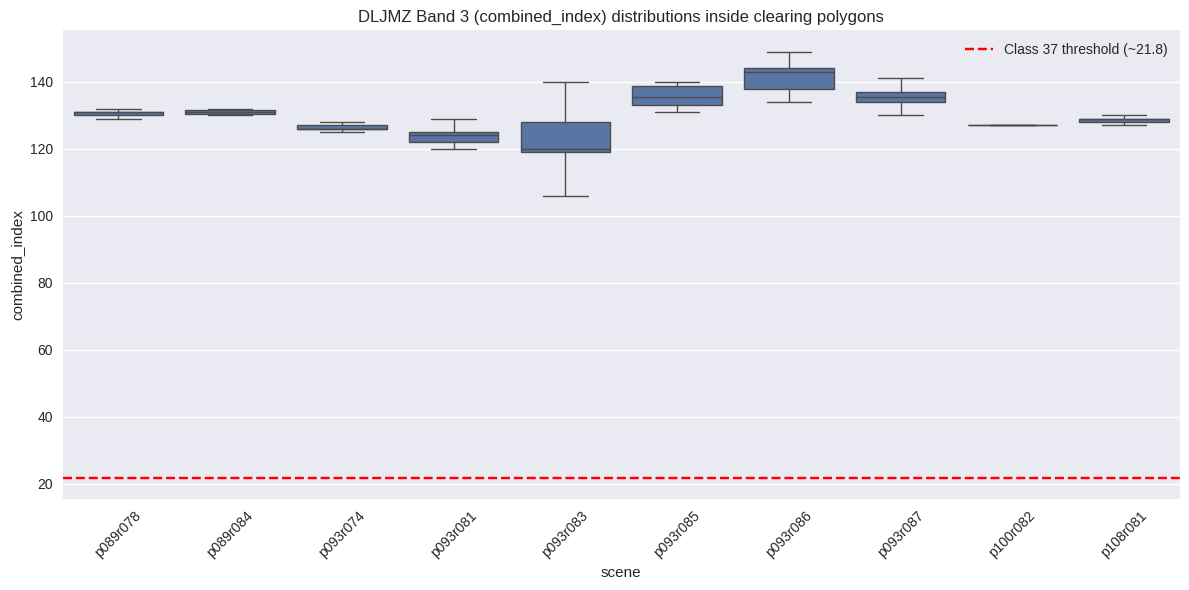

In [31]:
# ==========================================
# Visualise distributions (per scene)
# ==========================================

THRESHOLD_37 = 21.8  # legacy strong-clearing boundary

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=combined_long,
    x="scene",
    y="combined_index",
    showfliers=False,
)
plt.axhline(THRESHOLD_37, color="red", linestyle="--", label="Class 37 threshold (~21.8)")
plt.xticks(rotation=45)
plt.title("DLJMZ Band 3 (combined_index) distributions inside clearing polygons")
plt.legend()
plt.tight_layout()
plt.show()


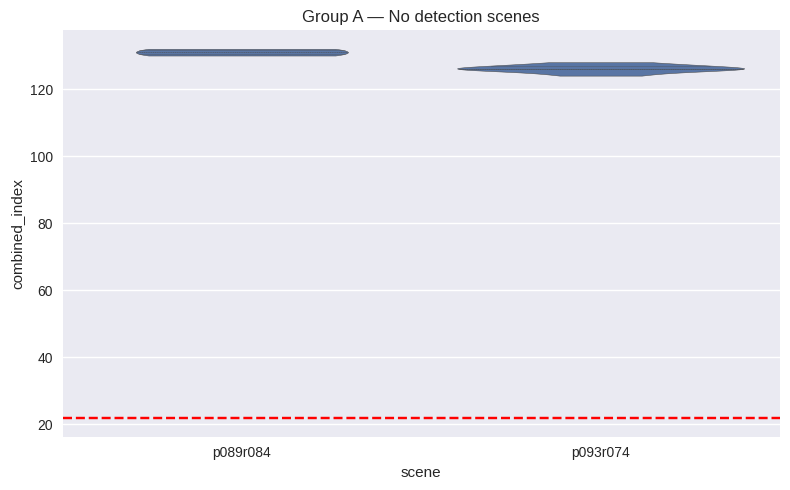

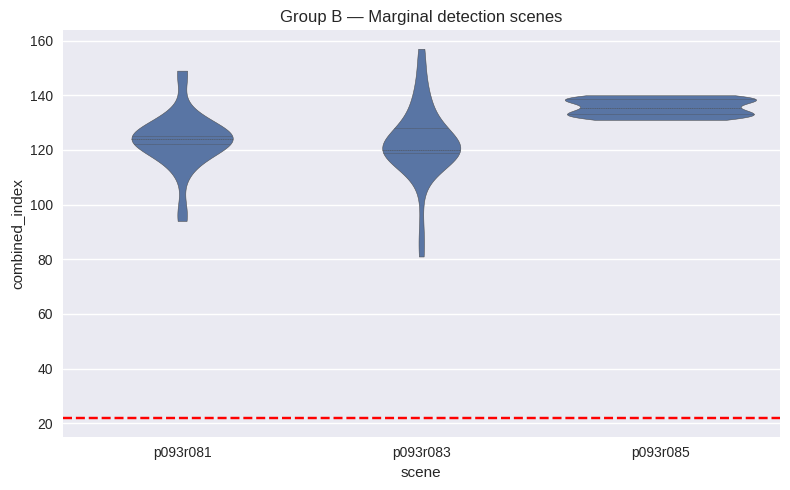

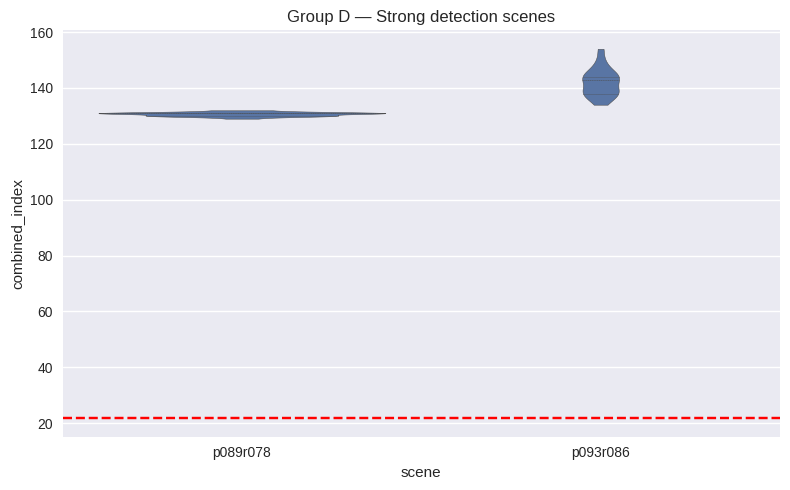

In [32]:
# ==========================================
# Focused comparison: Groups A, B, D
# (adjust lists if you want to refine)
# ==========================================

GROUP_A = ["p089r084", "p093r074"]
GROUP_B = ["p093r081", "p093r083", "p093r085"]
GROUP_D = ["p089r078", "p093r086"]

def plot_group(groups, title):
    subset = combined_long[combined_long["scene"].isin(groups)]
    plt.figure(figsize=(8, 5))
    sns.violinplot(
        data=subset,
        x="scene",
        y="combined_index",
        inner="quartile",
        cut=0,
    )
    plt.axhline(THRESHOLD_37, color="red", linestyle="--")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_group(GROUP_A, "Group A — No detection scenes")
plot_group(GROUP_B, "Group B — Marginal detection scenes")
plot_group(GROUP_D, "Group D — Strong detection scenes")


## Step 1 — Produce a percentile table on `*_combined_raw.img` (non-negotiable)

This step is the **primary evidence** used to decide calibration.  
We use **raw (unstretched)** `combined_index` values inside **known clearing polygons** (`IsClearing == 'y'`) and summarise them by **scene**.

---

### Why table first

- Visuals can mislead (stretching, colour scales, outliers)
- Threshold decisions must be based on **percentiles**
- This table is what you can **cite in a calibration report**

---

### What to compute (per scene, inside `IsClearing == 'y'` polygons)

For **raw combined index** (`*_combined_raw.img`), compute:

- `n_pixels` (or `n_vals`)
- `p05`
- `p25`
- `p50`
- `p75`
- `p90`
- `p95`
- `mean`
- `max` (for completeness only)

---

### Interpretation rules (critical)

| Pattern observed (raw combined) | Interpretation |
|---|---|
| `p95 ≈ 18–25` | **Threshold too high** (NDVI temporal signal weaker than FC) |
| `p90 < 21.8` but `p95 > 21.8` | **Marginal** detections → likely **weak-only** classes (34–36) |
| Broad percentile spread (e.g. p25≪p75) | **Healthy signal** (strong intra-polygon separation) |
| Narrow spread near 0 (p95 near 0) | **No clearing signal** (or clearing not expressed in NDVI window) |

---

### Output expected from this step

A per-scene table like:

- `scene`
- `n_vals`
- `p05 p25 p50 p75 p90 p95`
- `mean`
- `max_val`

This table is the decision foundation for choosing:
- threshold rescaling, and/or
- coefficient scaling

(Visualisations come **after** this.)


In [35]:
# ==========================================
# STEP 1 — Build per-scene percentile table
# Raw combined_index (*_combined_raw.img)
# Inside IsClearing == 'y' polygons
# ==========================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from pathlib import Path
import re


In [47]:
# ==========================================
# STEP 1A — Locate *_combined_raw.img for each scene
# (same style as Section 03)
# ==========================================

rx_comb_raw = re.compile(
    r"lztmre_(p\d+r\d+)_(\d{8})_combined_raw\.img$",
    re.IGNORECASE,
)

def discover_combined_raw_outputs(scene: str, root: Path = EDS_ROOT) -> pd.DataFrame:
    scene = scene.lower()
    cols = ["scene", "date", "path"]
    rows = []

    base = root / "ndvi" / scene / "diagnostics"
    if not base.exists():
        return pd.DataFrame(columns=cols)

    for p in base.glob("*.img"):
        m = rx_comb_raw.match(p.name)
        if not m:
            continue

        sc, date = m.group(1).lower(), m.group(2)
        if sc != scene:
            continue

        rows.append({
            "scene": sc,
            "date": date,
            "path": str(p),
        })

    return pd.DataFrame(rows, columns=cols)




def pick_best_combined_raw_for_case(scene: str) -> str | None:
    df = discover_combined_raw_outputs(scene)
    if df.empty:
        return None

    # take latest by date (string sort works for YYYYMMDD)
    df = df.sort_values("date", ascending=False)
    return df.iloc[0]["path"]



cases["new_combined_raw_img"] = cases["scene"].apply(
    pick_best_combined_raw_for_case
)

display(cases[["scene", "new_combined_raw_img"]])

missing = cases[cases["new_combined_raw_img"].isna()]
if len(missing):
    print("\nMissing *_combined_raw.img for:")
    display(missing[["scene", "end_date", "prev_shp"]])
else:
    print("\nFound *_combined_raw.img for all scenes.")


,scene,new_combined_raw_img
0,p089r078,/home/jovyan/scratch/eds/compat/files/ndvi/p08...
1,p089r084,/home/jovyan/scratch/eds/compat/files/ndvi/p08...
2,p093r074,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
3,p093r081,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
4,p093r083,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
5,p093r084,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
6,p093r085,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
7,p093r086,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
8,p093r087,/home/jovyan/scratch/eds/compat/files/ndvi/p09...
9,p100r082,None



Missing *_combined_raw.img for:


,scene,end_date,prev_shp
9,p100r082,20231022,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
10,p104r074,20231026,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...
11,p108r081,20231014,/home/jovyan/work-easi-eds/nvms_runs/run1/lzol...


In [51]:
# ==========================================
# STEP 1B — Extract raw combined values inside polygons
# ==========================================

def extract_raw_values(raster_path: str, geom) -> np.ndarray:
    with rasterio.open(raster_path) as src:
        nodata = src.nodata
        try:
            data, _ = mask(src, [geom], crop=True, filled=True, nodata=nodata)
        except ValueError:
            return np.array([])

        arr = data[0].astype("float32")
        valid = np.isfinite(arr)

        # treat 0 as nodata too (EDS convention for these ENVI products)
        valid &= (arr != 0)

        if nodata is not None:
            valid &= (arr != nodata)

        return arr[valid]


rows = []

for _, r in cases.iterrows():
    scene = r["scene"]
    prev_shp = r["prev_shp"]
    comb = r["new_combined_raw_img"]

    if pd.isna(prev_shp) or pd.isna(comb):
        continue

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) == 0:
        continue

    with rasterio.open(comb) as src:
        rcrs = src.crs
    if gdf.crs and rcrs and gdf.crs != rcrs:
        gdf = gdf.to_crs(rcrs)

    for idx, feat in gdf.iterrows():
        vals = extract_raw_values(comb, feat.geometry)
        if vals.size == 0:
            continue

        rows.append({
            "scene": scene,
            "poly_idx": idx,
            "n_vals": int(vals.size),
            "vals": vals,
        })

combined_raw_df = pd.DataFrame(rows)
print("Polygons with raw combined samples:", len(combined_raw_df))
display(combined_raw_df.head())


Polygons with raw combined samples: 86


,scene,poly_idx,n_vals,vals
0,p089r078,20,1731,"[68.7425, 56.817047, 79.15647, 62.4817, 51.784..."
1,p089r078,26,1104,"[40.3881, 41.83099, 51.29259, 42.923218, 47.76..."
2,p089r078,34,787,"[39.955727, 20.511358, 18.52566, 8.955734, 43...."
3,p089r078,49,456,"[34.575756, 36.30959, 30.780647, 41.15275, 36...."
4,p089r078,79,239,"[33.829857, 52.52162, 24.190628, 36.47481, 35...."


In [54]:
# ==========================================
# STEP 1C — Build per-scene percentile table (raw combined)
# ==========================================

combined_raw_long = (
    combined_raw_df
    .explode("vals")
    .rename(columns={"vals": "combined_raw"})
)

combined_raw_long["combined_raw"] = combined_raw_long["combined_raw"].astype(float)

def pct(s, p):
    return float(np.percentile(s, p))

scene_raw_summary = (
    combined_raw_long
    .groupby("scene", as_index=False)
    .agg(
        n_vals=("combined_raw", "count"),
        p05=("combined_raw", lambda s: pct(s, 5)),
        p10=("combined_raw", lambda s: pct(s, 10)),
        p25=("combined_raw", lambda s: pct(s, 25)),
        p50=("combined_raw", lambda s: pct(s, 50)),
        p75=("combined_raw", lambda s: pct(s, 75)),
        p90=("combined_raw", lambda s: pct(s, 90)),
        p95=("combined_raw", lambda s: pct(s, 95)),
        mean=("combined_raw", "mean"),
        max_val=("combined_raw", "max"),
        min_val=("combined_raw", "min"),
    )
)

display(scene_raw_summary.sort_values("scene"))


,scene,n_vals,p05,p10,p25,p50,p75,p90,p95,mean,max_val,min_val
0,p089r078,4990,22.560838,31.544656,49.920710,119.123783,169.552219,184.273325,189.507996,111.620608,429.176270,-33.125900
1,p089r084,1710,-16.603821,-13.950439,-7.973458,-4.592213,0.160744,7.575202,14.562797,-3.107825,69.540222,-33.863361
2,p093r074,159,-16.297243,-14.828283,-2.058023,4.415658,10.950497,20.157906,21.232154,3.595274,22.566654,-26.117701
3,p093r081,28717,-48.308523,-32.726216,-8.576597,13.727245,31.979177,43.253789,50.164552,8.805256,271.939087,-540.241455
4,p093r083,30417,-1.316055,0.642512,2.147119,3.414886,4.834235,19.434408,35.041100,6.006591,142.805115,-176.926178
5,p093r085,1655,-56.473272,-51.203470,-27.525133,59.341755,89.917206,103.481686,113.696463,37.784897,201.901581,-109.897217
6,p093r086,2666,-11.255493,14.864653,55.450653,116.449211,170.727627,206.548805,263.382034,116.115877,438.705505,-116.394470
7,p093r087,5733,208.520322,460.628204,513.362915,562.048950,599.514038,616.681958,659.997888,534.512582,754.190796,-113.447617


In [55]:
# ==========================================
# STEP 1D — Convert polygon arrays to long form
# ==========================================

combined_raw_long = (
    combined_raw_df
    .explode("vals")
    .rename(columns={"vals": "combined_raw"})
)

combined_raw_long["combined_raw"] = combined_raw_long["combined_raw"].astype(float)

print("Total raw pixel samples:", len(combined_raw_long))
display(combined_raw_long.head())


Total raw pixel samples: 76047


,scene,poly_idx,n_vals,combined_raw
0,p089r078,20,1731,68.742500
0,p089r078,20,1731,56.817047
0,p089r078,20,1731,79.156471
0,p089r078,20,1731,62.481701
0,p089r078,20,1731,51.784855


## Step 2 (SECOND): Visualise — but only raw combined, not stretched

Once you’ve seen the table:

What to plot

 - Histograms or KDEs of raw combined_index

 - One plot per scene group (PASS / WEAK / FAIL)

 - Overlay vertical lines at:

   - 21.8

   - 39.5

   - 58.1

What visuals are good for

 - Confirming the table isn’t hiding multimodal behaviour

 - Showing stakeholders why polygons fail

 - Spotting bimodal cases (partial clearing)

What visuals are not for

 - Choosing thresholds

 - Deciding pass/fail

 - Comparing stretched outputs (DLJMZ band 3)

In [56]:
# ==========================================
# STEP 2 — Visualise raw combined distributions
# (supporting evidence only)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns


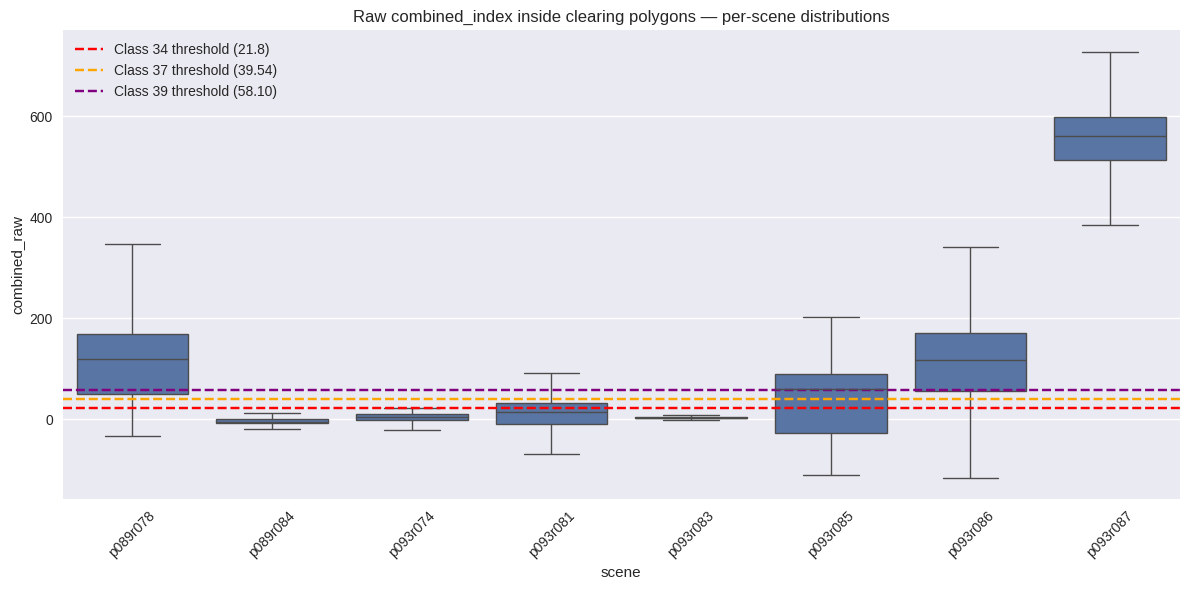

In [57]:
# ==========================================
# STEP 2A — Boxplot by scene with legacy thresholds
# ==========================================

THRESH_34 = 21.8
THRESH_37 = 39.54
THRESH_39 = 58.10

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=combined_raw_long,
    x="scene",
    y="combined_raw",
    showfliers=False,
)
plt.axhline(THRESH_34, color="red", linestyle="--", label="Class 34 threshold (21.8)")
plt.axhline(THRESH_37, color="orange", linestyle="--", label="Class 37 threshold (39.54)")
plt.axhline(THRESH_39, color="purple", linestyle="--", label="Class 39 threshold (58.10)")
plt.xticks(rotation=45)
plt.title("Raw combined_index inside clearing polygons — per-scene distributions")
plt.legend()
plt.tight_layout()
plt.show()


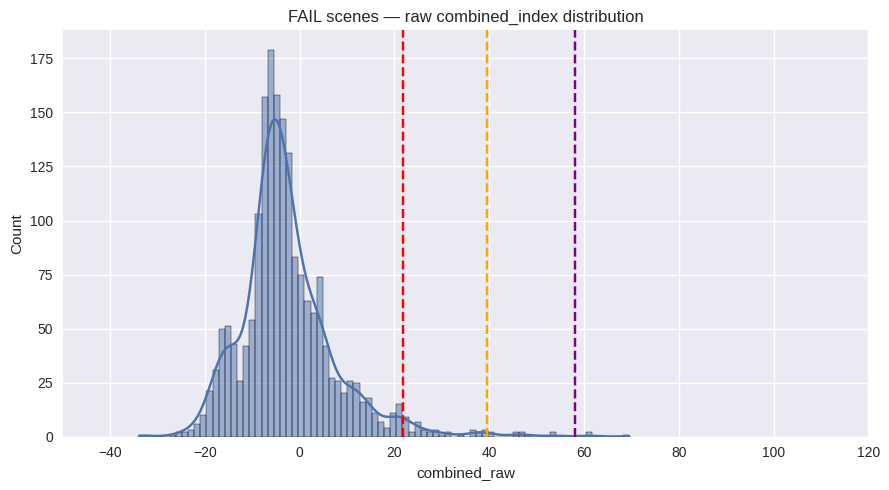

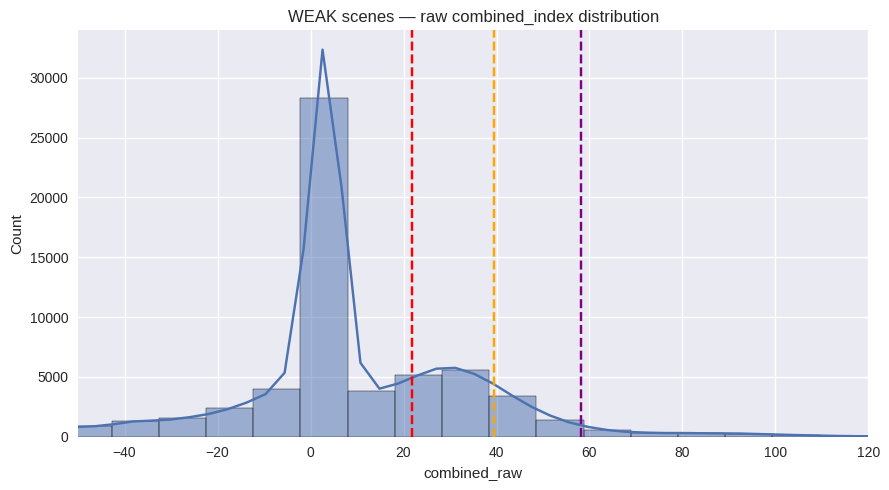

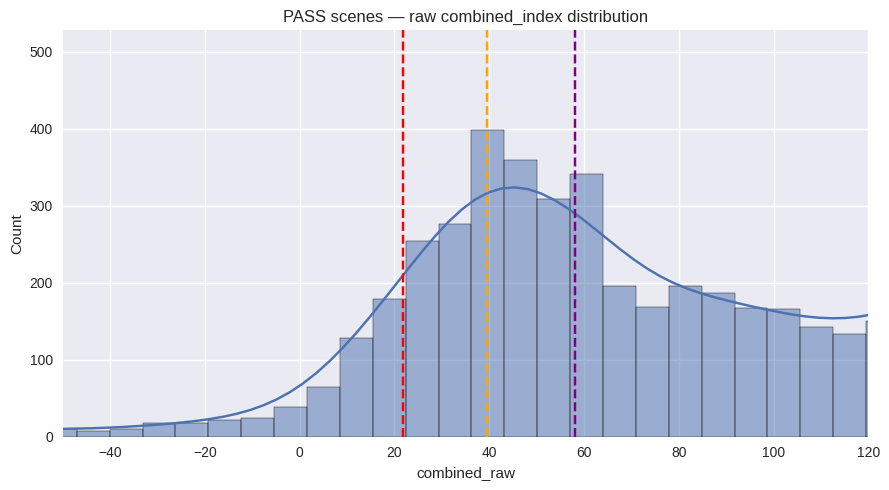

In [58]:
# ==========================================
# STEP 2B — Scene-grouped histograms (PASS / WEAK / FAIL)
# Define groups based on your earlier match_rate table
# ==========================================

GROUP_PASS = ["p089r078", "p093r086"]                 # strong pass examples
GROUP_WEAK = ["p093r081", "p093r083", "p093r085"]     # marginal
GROUP_FAIL = ["p089r084", "p093r074"]                 # no detection

def plot_hist(group_scenes, title, bins=80, xlim=None):
    sub = combined_raw_long[combined_raw_long["scene"].isin(group_scenes)]
    plt.figure(figsize=(9, 5))
    sns.histplot(sub["combined_raw"], bins=bins, kde=True)
    plt.axvline(THRESH_34, color="red", linestyle="--")
    plt.axvline(THRESH_37, color="orange", linestyle="--")
    plt.axvline(THRESH_39, color="purple", linestyle="--")
    if xlim:
        plt.xlim(*xlim)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_hist(GROUP_FAIL, "FAIL scenes — raw combined_index distribution", xlim=(-50, 120))
plot_hist(GROUP_WEAK, "WEAK scenes — raw combined_index distribution", xlim=(-50, 120))
plot_hist(GROUP_PASS, "PASS scenes — raw combined_index distribution", xlim=(-50, 120))


In [ ]:
aa

# Visualise the tiles

In [ ]:
import matplotlib.pyplot as plt
from rasterio.plot import show

def plot_dljmz(scene: str, max_polys=100):
    row = cases[cases["scene"] == scene].iloc[0]
    dlj = row["new_dljmz_img"]
    prev_shp = row["prev_shp"]

    if pd.isna(dlj):
        print("No dljmz for", scene)
        return

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()
    if len(gdf) > max_polys:
        gdf = gdf.sample(max_polys, random_state=42)

    with rasterio.open(dlj) as src:
        fig, ax = plt.subplots(figsize=(10,10))
        # dljmz is 3-band; show as RGB (bands 1,2,3)
        show(src, ax=ax, title=f"{scene} — dljmz RGB + prev clearing polygons")
        if gdf.crs and src.crs and gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
        gdf.boundary.plot(ax=ax, linewidth=1)
        plt.show()

# Call function:
plot_dljmz("p093r081")


In [ ]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import geopandas as gpd
import pandas as pd

def plot_dljmz_rgb(scene: str, max_polys=200):
    row = cases[cases["scene"] == scene].iloc[0]
    dlj = row["new_dljmz_img"]
    prev_shp = row["prev_shp"]

    if pd.isna(dlj):
        print("No dljmz for", scene)
        return

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) == 0:
        print(f"{scene}: no IsClearing=='y' polygons")
        return

    if len(gdf) > max_polys:
        gdf = gdf.sample(max_polys, random_state=42)

    with rasterio.open(dlj) as src:
        if gdf.crs and src.crs and gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)

        fig, ax = plt.subplots(figsize=(12, 12))
        # Explicit RGB bands:
        show(src, ax=ax, indexes=(1, 2, 3))
        gdf.boundary.plot(ax=ax, linewidth=1, color="cyan")
        ax.set_title(f"{scene} — DLJMZ RGB (R=spectral, G=s_test, B=combined) + clearing polygons")
        ax.axis("off")
        plt.show()

# Example
plot_dljmz_rgb("p093r081")


In [ ]:
import numpy as np

def plot_dljmz_bands(scene: str, max_polys=200):
    row = cases[cases["scene"] == scene].iloc[0]
    dlj = row["new_dljmz_img"]
    prev_shp = row["prev_shp"]

    if pd.isna(dlj):
        print("No dljmz for", scene)
        return

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) == 0:
        print(f"{scene}: no IsClearing=='y' polygons")
        return

    if len(gdf) > max_polys:
        gdf = gdf.sample(max_polys, random_state=42)

    titles = {
        1: "Band 1 — spectral_stretch (uint8)",
        2: "Band 2 — s_test stretch (uint8)",
        3: "Band 3 — combined_stretch (uint8)",
        4: "Band 4 — clearing_prob (0–200 uint8)",
    }

    with rasterio.open(dlj) as src:
        if gdf.crs and src.crs and gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)

        nodata = src.nodata

        fig, axes = plt.subplots(1, min(src.count, 4), figsize=(20, 6))
        if src.count == 1:
            axes = [axes]

        for i in range(1, min(src.count, 4) + 1):
            arr = src.read(i).astype(np.float32)
            if nodata is not None:
                arr[arr == nodata] = np.nan

            # These are already stretched layers, so show as-is:
            im = axes[i-1].imshow(arr, cmap="gray", vmin=1, vmax=255)
            gdf.boundary.plot(ax=axes[i-1], linewidth=0.8, color="cyan")
            axes[i-1].set_title(titles[i])
            axes[i-1].axis("off")
            plt.colorbar(im, ax=axes[i-1], shrink=0.7)

        plt.tight_layout()
        plt.show()

# Example
plot_dljmz_bands("p093r081")


## SECTION 04 — Zonal stats (previous-run polygons → new NDVI raster)

In [ ]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


In [ ]:
DLLMZ_CLASSES = {
    10: "#bdbdbd",  # no change
    34: "#ffffb2",
    35: "#fed976",
    36: "#feb24c",
    37: "#fd8d3c",
    38: "#f03b20",
    39: "#bd0026",
}

DLLMZ_ORDER = [10, 34, 35, 36, 37, 38, 39]
DLLMZ_CMAP = ListedColormap([DLLMZ_CLASSES[v] for v in DLLMZ_ORDER])

def to_index(arr):
    out = np.full(arr.shape, np.nan, dtype="float32")
    for i, v in enumerate(DLLMZ_ORDER):
        out[arr == v] = i
    return out


In [ ]:
import matplotlib.patches as mpatches

def add_dllmz_legend(ax, *, loc="lower right", title="dllmz classes"):
    handles = [
        mpatches.Patch(
            color=DLLMZ_CLASSES[v],
            label=str(v)
        )
        for v in DLLMZ_ORDER
    ]
    ax.legend(
        handles=handles,
        title=title,
        loc=loc,
        frameon=True,
        fontsize=9,
        title_fontsize=10,
    )


In [ ]:
def inspect_polygon(
    scene: str,
    poly_idx: int,
    *,
    buffer_m=500,
    prefer_class=37,
    min_pref_pct=0.01,
):
    row = cases[cases["scene"] == scene].iloc[0]
    dll = row["new_dllmz_img"]
    prev_shp = row["prev_shp"]

    gdf = gpd.read_file(prev_shp)
    poly = gdf.loc[poly_idx]

    with rasterio.open(dll) as src:
        # reproject polygon
        if gdf.crs != src.crs:
            poly_geom = gpd.GeoSeries([poly.geometry], crs=gdf.crs).to_crs(src.crs).iloc[0]
        else:
            poly_geom = poly.geometry

        # ---------- POLYGON-ONLY (STATS) ----------
        data_poly, tr_poly = mask(src, [poly_geom], crop=True, filled=False)
        marr = data_poly[0]

        vals = marr.data[~marr.mask].astype(int)

        classes, counts = np.unique(vals, return_counts=True)
        total = counts.sum()

        counts_dict = dict(zip(classes, counts))

        max_in_poly = vals.max()
        pct_ge_pref = np.isin(vals, [v for v in DLLMZ_ORDER if v >= prefer_class]).mean()
        pct_any_change = np.isin(vals, [34,35,36,37,38,39]).mean()
        pct_nochg = (vals == 10).mean()

        maj_change_class = max(
            [v for v in counts_dict if v != 10],
            key=lambda v: counts_dict[v],
        )
        maj_change_pct = counts_dict[maj_change_class] / (total - counts_dict.get(10, 0))

        verdict = (
            "PREFERRED_PASS"
            if pct_ge_pref >= min_pref_pct
            else "FAIL"
        )

        print(f"\n{scene} | poly {poly_idx} — POLYGON-ONLY counts")
        for v in DLLMZ_ORDER:
            if v in counts_dict:
                print(f"  class {v}: {counts_dict[v]:6d} px ({counts_dict[v]/total:5.1%})")

        print(f"  maj_change : {maj_change_class} ({maj_change_pct:.1%})")
        print(f"  max_in_poly: {max_in_poly}")
        print(f"  pct_any_change={pct_any_change:.3f} | pct>={prefer_class}={pct_ge_pref:.3f} | pct_nochg={pct_nochg:.3f}")
        print(f"  {verdict}")

        # ---------- BUFFERED CONTEXT PLOT ----------
        data_buf, tr_buf = mask(src, [poly_geom.buffer(buffer_m)], crop=True, filled=True)
        idx_buf = to_index(data_buf[0])

        h, w = idx_buf.shape
        xmin, ymax = tr_buf * (0, 0)
        xmax, ymin = tr_buf * (w, h)

        # fig, ax = plt.subplots(figsize=(7, 7))
        # ax.imshow(
        #     idx_buf,
        #     cmap=DLLMZ_CMAP,
        #     interpolation="nearest",
        #     extent=[xmin, xmax, ymin, ymax],
        #     origin="upper",
        # )
        # gpd.GeoSeries([poly_geom], crs=src.crs).boundary.plot(ax=ax, color="black", linewidth=2)
        # ax.set_title(
        #     f"{scene} | poly {poly_idx}\n"
        #     f"max_in_poly={max_in_poly}, pct>={prefer_class}={pct_ge_pref:.2f}, "
        #     f"maj_change={maj_change_class}({maj_change_pct:.2f})\n"
        #     f"{verdict} (STATS polygon-only; PLOT buffered)"
        # )
        # plt.show()
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(
            idx_buf,
            cmap=DLLMZ_CMAP,
            interpolation="nearest",
            extent=[xmin, xmax, ymin, ymax],
            origin="upper",
        )
        
        gpd.GeoSeries([poly_geom], crs=src.crs).boundary.plot(
            ax=ax, color="black", linewidth=2
        )
        
        add_dllmz_legend(ax)
        
        ax.set_title(
            f"{scene} | poly {poly_idx}\n"
            f"max_in_poly={max_in_poly}, pct>={prefer_class}={pct_ge_pref:.2f}, "
            f"maj_change={maj_change_class}({maj_change_pct:.2f})\n"
            f"{verdict} (STATS polygon-only; PLOT buffered)"
        )
        plt.show()

        # ---------- POLYGON-ONLY TRANSPARENT PLOT ----------
        idx_poly = to_index(marr.data.astype(int))
        idx_poly[marr.mask] = np.nan

        h2, w2 = idx_poly.shape
        xmin2, ymax2 = tr_poly * (0, 0)
        xmax2, ymin2 = tr_poly * (w2, h2)

        # fig2, ax2 = plt.subplots(figsize=(6, 6))
        # ax2.imshow(
        #     idx_poly,
        #     cmap=DLLMZ_CMAP,
        #     interpolation="nearest",
        #     extent=[xmin2, xmax2, ymin2, ymax2],
        #     origin="upper",
        # )
        # ax2.set_title(f"{scene} | poly {poly_idx} — polygon-only (truth)")
        # plt.show()

        fig2, ax2 = plt.subplots(figsize=(10, 10))
        ax2.imshow(
            idx_poly,
            cmap=DLLMZ_CMAP,
            interpolation="nearest",
            extent=[xmin2, xmax2, ymin2, ymax2],
            origin="upper",
        )
        
        add_dllmz_legend(ax2)
        
        ax2.set_title(f"{scene} | poly {poly_idx} — polygon-only (truth)")
        plt.show()



In [ ]:
# inspect_polygon("p089r078", 49, buffer_m=500, prefer_class=37)
# inspect_polygon("p089r078", 34, buffer_m=500, prefer_class=37)

In [ ]:
def inspect_all_polygons(
    scene: str,
    *,
    buffer_m=500,
    prefer_class=37,
):
    row = cases[cases["scene"] == scene].iloc[0]
    prev_shp = row["prev_shp"]

    gdf = gpd.read_file(prev_shp)

    print(f"\nScene {scene} — {len(gdf)} polygons\n")

    for idx in gdf.index:
        try:
            inspect_polygon(
                scene,
                idx,
                buffer_m=buffer_m,
                prefer_class=prefer_class,
            )
        except Exception as e:
            print(f"⚠️ poly {idx} failed: {e}")


In [ ]:
inspect_all_polygons(
    # "p089r078",
    # "p089r084",
    "p093r081",
    buffer_m=500,
    prefer_class=37,
)


## SECTION 05 — Spatial overlap / IoU (if you have NEW polygons)

In [ ]:
import re

# Adjust to match your output naming for NEW event polygons
# We'll look for any shapefile containing scene and keywords.
NEW_POLY_KEYWORDS = ["eds", "event", "detect", "clearing", "dl", "dlj", "dll", "dwm", "polygons"]

def find_new_polygons_for_scene(scene: str, root: Path = EDS_ROOT) -> str | None:
    scene = scene.lower()
    candidates = []
    for kw in NEW_POLY_KEYWORDS:
        candidates += list(root.rglob(f"*{scene}*{kw}*.shp"))
    candidates = [p for p in candidates if p.is_file()]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return str(candidates[0])

cases["new_poly_shp"] = cases["scene"].apply(lambda s: find_new_polygons_for_scene(s, EDS_ROOT))
display(cases[["scene", "prev_shp", "new_poly_shp"]])


In [ ]:
import re

# Adjust to match your output naming for NEW event polygons
# We'll look for any shapefile containing scene and keywords.
NEW_POLY_KEYWORDS = ["eds", "event", "detect", "clearing", "dl", "dlj", "dll", "dwm", "polygons"]

def find_new_polygons_for_scene(scene: str, root: Path = EDS_ROOT) -> str | None:
    scene = scene.lower()
    candidates = []
    for kw in NEW_POLY_KEYWORDS:
        candidates += list(root.rglob(f"*{scene}*{kw}*.shp"))
    candidates = [p for p in candidates if p.is_file()]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return str(candidates[0])

cases["new_poly_shp"] = cases["scene"].apply(lambda s: find_new_polygons_for_scene(s, EDS_ROOT))
display(cases[["scene", "prev_shp", "new_poly_shp"]])


In [ ]:
import geopandas as gpd

def ensure_projected(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Ensure data is in a projected CRS for area calculations.
    If already projected, keep it. If geographic, project to EPSG:3577 (AU Albers).
    """
    if gdf.crs is None:
        return gdf
    if gdf.crs.is_geographic:
        return gdf.to_crs("EPSG:3577")
    return gdf

overlap_rows = []

for _, row in cases.iterrows():
    scene = row["scene"]
    prev_shp = row["prev_shp"]
    new_shp = row.get("new_poly_shp", None)

    if pd.isna(prev_shp) or pd.isna(new_shp):
        continue

    prev = gpd.read_file(prev_shp)
    new = gpd.read_file(new_shp)

    # Filter prev to IsClearing == y if exists
    if "IsClearing" in prev.columns:
        prev = prev[prev["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(prev) == 0 or len(new) == 0:
        continue

    # Use projected CRS for areas
    prev = ensure_projected(prev)
    new = ensure_projected(new)

    # Dissolve into one footprint per dataset (simpler & robust)
    prev_u = prev.geometry.unary_union
    new_u  = new.geometry.unary_union

    inter = prev_u.intersection(new_u)
    union = prev_u.union(new_u)

    prev_area = prev_u.area
    new_area  = new_u.area
    inter_area = inter.area
    union_area = union.area

    iou = (inter_area / union_area) if union_area else np.nan
    prev_covered = (inter_area / prev_area) if prev_area else np.nan
    new_precision = (inter_area / new_area) if new_area else np.nan

    overlap_rows.append({
        "scene": scene,
        "prev_shp": prev_shp,
        "new_poly_shp": new_shp,
        "prev_area_m2": float(prev_area),
        "new_area_m2": float(new_area),
        "intersection_m2": float(inter_area),
        "union_m2": float(union_area),
        "iou": float(iou),
        "prev_covered": float(prev_covered),   # recall-ish
        "new_precision": float(new_precision), # precision-ish
    })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df.sort_values("scene"))
print("Overlap scenes:", len(overlap_df))


## SECTION 06 — Outputs + Matplotlib QA plots

In [ ]:
OUT_DIR = Path("./validation_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

zonal_csv = OUT_DIR / "zonal_polygon_stats.csv"
scene_csv = OUT_DIR / "scene_zonal_summary.csv"
zonal_df.to_csv(zonal_csv, index=False)
scene_zonal_summary.to_csv(scene_csv, index=False)

print("Wrote:", zonal_csv)
print("Wrote:", scene_csv)

if "overlap_df" in globals() and len(overlap_df):
    overlap_csv = OUT_DIR / "polygon_overlap_iou.csv"
    overlap_df.to_csv(overlap_csv, index=False)
    print("Wrote:", overlap_csv)


In [ ]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

def quick_plot_scene(scene: str, *, max_polys=50):
    row = cases[cases["scene"] == scene].iloc[0]
    prev_shp = row["prev_shp"]
    new_tif  = row["new_ndvi_tif"]

    gdf = gpd.read_file(prev_shp)
    if "IsClearing" in gdf.columns:
        gdf = gdf[gdf["IsClearing"].astype(str).str.lower().eq("y")].copy()

    if len(gdf) > max_polys:
        gdf = gdf.sample(max_polys, random_state=42)

    with rasterio.open(new_tif) as src:
        fig, ax = plt.subplots(figsize=(10, 10))
        show(src, ax=ax, title=f"{scene} — NEW NDVI raster + prev clearing polygons")
        # reproject polygons to raster CRS
        if gdf.crs and src.crs and gdf.crs != src.crs:
            gdf = gdf.to_crs(src.crs)
        gdf.boundary.plot(ax=ax, linewidth=1)
        plt.show()

# Example usage:
# quick_plot_scene("p089r078")


In [ ]:
thr_col = f"pct_below_{CLEAR_THR:+.2f}"

fig, ax = plt.subplots(figsize=(10, 5))
zonal_df[thr_col].dropna().hist(bins=30, ax=ax)
ax.set_title(f"Distribution: % pixels with NDVI < {CLEAR_THR:+.2f}")
ax.set_xlabel(thr_col)
ax.set_ylabel("count")
plt.show()


## New Section

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize

# -----------------------------
# CONFIG: update these
# -----------------------------

# Root where your EDS outputs are
EDS_ROOT = Path("/home/jovyan/scratch/eds/compat/files")

# Your validation polygons (must contain field IsClearing with 'y' / 'n')
VALIDATION_SHP = Path("/home/jovyan/work/eds_validation/your_validation_polygons.shp")

# Which scenes to analyse (leave empty to auto-discover all scenes under EDS_ROOT)
SCENES = []  # e.g. ["p089r078", "p089r084"]

# DLL classes of interest
CHANGE_CLASSES = [34, 35, 36, 37, 38, 39]
STRONG_CLASS_MIN = 37

# Nodata handling: most of your pipeline uses 0/0.0
NODATA_VALUES = {0, 0.0, 255}  # include 255 just in case of stretched uint8


## Discover DLLMZ + DLJMZ files per scene

In [ ]:
def discover_products(root: Path):
    """
    Find DLLMZ + DLJMZ rasters. Supports .img/.tif/.tiff.
    Returns dict: scene -> {"dll": Path, "dlj": Path}
    """
    exts = (".img", ".tif", ".tiff")
    out = {}

    # Heuristic search: look for filenames containing dll/dlj
    # Adjust patterns if your naming differs.
    for p in root.rglob("*"):
        if not p.is_file():
            continue
        if p.suffix.lower() not in exts:
            continue

        name = p.name.lower()

        # try to extract scene like p089r078 anywhere in the path/name
        m = re.search(r"(p\d{3}r\d{3})", str(p))
        if not m:
            continue
        scene = m.group(1)

        out.setdefault(scene, {})
        if "dll" in name:
            out[scene]["dll"] = p
        if "dlj" in name:
            out[scene]["dlj"] = p

    # keep only scenes that have at least dll (dlj is diagnostic, but optional)
    out = {k: v for k, v in out.items() if "dll" in v}
    return out

products = discover_products(EDS_ROOT)

if SCENES:
    products = {s: products[s] for s in SCENES if s in products}

len(products), list(products)[:10], {k: list(v.keys()) for k, v in list(products.items())[:5]}


In [ ]:
## Load validation polygons + keep only known clearing

In [ ]:
gdf_all = gpd.read_file(VALIDATION_SHP)
assert "IsClearing" in gdf_all.columns, "Validation shapefile must have IsClearing field."

gdf = gdf_all[gdf_all["IsClearing"].astype(str).str.lower().eq("y")].copy()
gdf = gdf.reset_index(drop=True)

len(gdf), gdf.crs
